# Pre-Fit and Post-Fit plots
This notebook plots the pre/post-fit plots using the outputs from running runcards.py and runcombine.py. Firstly, make a `fitDiagnosticsTest.root` by running the `fitdiagnostics.sh` script for a particular signal point.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import hist.intervals
import numpy as np
import warnings
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import chi2
import mplhep as hep
import os
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerLine2D
import plot_utils
from matplotlib import ticker
import re

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.max_open_warning': 0})
matplotlib.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 70
plt.style.use(hep.style.CMS)
hep.style.use("CMS")

In [2]:
AN_label = "/home/submit/"+os.environ['USER']+"/SUEP/AN-23-183/images/{}.pdf"
save_to_AN = False

In [3]:
filename = "../cards/WH_3_9/cards-SUEP_mS125.000_mPhi3.000_T3.000_modegeneric/fitDiagnosticsTest.root" # replace with your actual ROOT file path
file = uproot.open(filename)

In [4]:
sames = {}
for k in file.keys():
    s = k
    if 'ch2' in s:
        index = s.find('ch2') + len('ch2')
    elif 'ch1' in s:
        index = s.find('ch1') + len('ch1')
    else:
        index = 0
    s = s[index:]
    if s in sames.keys():
        sames[s].append(k)
    else:
        sames[s] = []
        sames[s].append(k)

for list in sames.keys():
    print(sames[list])

['shapes_prefit;1']
['shapes_prefit/SR_A;1']
['shapes_prefit/SR_A/data;1']
['shapes_prefit/SR_A/bkg;1']
['shapes_prefit/SR_A/Signal;1']
['shapes_prefit/SR_A/total;1']
['shapes_prefit/SR_A/total_signal;1']
['shapes_prefit/SR_A/total_background;1']
['shapes_prefit/SR_A/total_covar;1']
['shapes_prefit/SR_B;1']
['shapes_prefit/SR_B/data;1']
['shapes_prefit/SR_B/bkg;1']
['shapes_prefit/SR_B/Signal;1']
['shapes_prefit/SR_B/total;1']
['shapes_prefit/SR_B/total_signal;1']
['shapes_prefit/SR_B/total_background;1']
['shapes_prefit/SR_B/total_covar;1']
['shapes_prefit/SR_C;1']
['shapes_prefit/SR_C/data;1']
['shapes_prefit/SR_C/bkg;1']
['shapes_prefit/SR_C/Signal;1']
['shapes_prefit/SR_C/total;1']
['shapes_prefit/SR_C/total_signal;1']
['shapes_prefit/SR_C/total_background;1']
['shapes_prefit/SR_C/total_covar;1']
['shapes_prefit/SR_D;1']
['shapes_prefit/SR_D/data;1']
['shapes_prefit/SR_D/bkg;1']
['shapes_prefit/SR_D/Signal;1']
['shapes_prefit/SR_D/total;1']
['shapes_prefit/SR_D/total_signal;1']
['s

In [5]:
def compute_poisson_interval(values, confidence=0.6827):
    alpha = 1 - confidence
    low = chi2.ppf(alpha / 2., 2 * values) / 2
    high = chi2.ppf(1. - alpha / 2., 2 * (values + 1)) / 2
    #low[np.isnan(low)] = 0
    return low, high

lumis = {
    "2016_apv": 19497.914,
    "2016": 16810.813,
    "2017": 41471.589,
    "2018": 59817.406,
    "all": 19497.914 + 16810.813 + 41471.589 + 59817.406,
}

def lumiLabel(year):
    if year in ["2017", "2018"]:
        return round(lumis[year] / 1000, 1)
    elif year == "2016":
        return round((lumis[year] + lumis[year + "_apv"]) / 1000, 1)
    elif year == 'all':
        return round(lumis[year] / 1000, 1)

In [20]:
def read_post_fit_file(postFitFile, bins, regions):
   
    payload, payload_err = {}, {}
    for region in regions:
        
        payload[region], payload_err[region] = {}, {}

        for fit in ['fit_s', 'fit_b', 'prefit']:
                
            payload[region][fit], payload_err[region][fit] = {}, {}
            payload[region]['data'], payload_err[region]['data'] = {}, {}

            for bin in bins:

                name = 'shapes_{}/{};1'.format(fit, region+"_"+bin)
                
                payload[region][fit][bin] = postFitFile[name]['total_background;1'].values()[0]
                payload_err[region][fit][bin] = np.sqrt(postFitFile[name]['total_covar;1'].to_numpy()[0][0][0])

                payload[region]['data'][bin] = postFitFile[name]['data;1'].values()[1][0]
                payload_err[region]['data'][bin] = np.array(compute_poisson_interval(payload[region]['data'][bin]))

    return payload, payload_err

def create_plot_objects(_rpayload, _rpayload_err, lepton='', channelnum=''):

    hist_defs = {
        'A': {'channels': ['A'], 'bins': [10, 20]},
        'B': {'channels': ['B'], 'bins': [20, 30]},
        'C': {'channels': ['C'], 'bins': [30, 120]},
        'D': {'channels': ['D'], 'bins': [10, 20]},
        'E': {'channels': ['E'], 'bins': [20, 30]},
        'F': {'channels': ['F_Fbin0', 'F_Fbin1', 'F_Fbin2', 'F_Fbin3', 'F_Fbin4'], 'bins': [30, 40, 50, 60, 80, 120]},
        'G': {'channels': ['G'], 'bins': [10, 20]},
        'H': {'channels': ['H'], 'bins': [20, 30]},
        'SR': {'channels': ['SR_SRbin0', 'SR_SRbin1', 'SR_SRbin2', 'SR_SRbin3', 'SR_SRbin4'], 'bins': [30, 40, 50, 60, 80, 120]},
    }

    hist_defs = {
        'ABC': {'channels': ['A', 'B', 'C'], 'bins': [10, 20, 30, 120]},
        'DEF': {'channels': ['D', 'E', 'F_Fbin0', 'F_Fbin1', 'F_Fbin2', 'F_Fbin3', 'F_Fbin4'], 'bins': [10, 20, 30, 40, 50, 60, 80, 120]},
        'GHSR': {'channels': ['G', 'H', 'SR_SRbin0', 'SR_SRbin1', 'SR_SRbin2', 'SR_SRbin3', 'SR_SRbin4'], 'bins': [10, 20, 30, 40, 50, 60, 80, 120]},
        'SR': {'channels': ['SR_SRbin0', 'SR_SRbin1', 'SR_SRbin2', 'SR_SRbin3', 'SR_SRbin4'], 'bins': [30, 40, 50, 60, 80, 120]},
    }

    if channelnum == 'ch1':
        hist_defs = {
            'B': {'channels': ['E1'], 'bins': [14, 21]},
            'A': {'channels': ['E2'], 'bins': [0, 14]},
            'E': {'channels': ['D1'], 'bins': [14, 21]},
            'D': {'channels': ['D2'], 'bins': [0, 14]},
            'H': {'channels': ['C1'], 'bins': [14, 21]},
            'G': {'channels': ['C2'], 'bins': [0, 14]},
            'F': {'channels': ['B1_B1bin1','B1_B1bin2','B1_B1bin3','B1_B1bin4', 'B1_B1bin5','B1_B1bin6','B1_B1bin7','B1_B1bin8'], 'bins': [21, 26 , 31, 36, 41, 46, 51, 56, 80]},
            'C': {'channels': ['B2_B2bin1','B2_B2bin2','B2_B2bin3','B2_B2bin4', 'B2_B2bin5','B2_B2bin6','B2_B2bin7','B2_B2bin8'], 'bins': [21, 26 , 31, 36, 41, 46, 51, 56, 80]},
            'SR': {'channels': ['SR_SRbin1','SR_SRbin2','SR_SRbin3','SR_SRbin4', 'SR_SRbin5','SR_SRbin6','SR_SRbin7','SR_SRbin8'], 'bins': [21, 26 , 31, 36, 41, 46, 51, 56, 80]},
        }

    for region in hist_defs.keys():
        hist_defs[region]['channels'] = [lepton+channel for channel in hist_defs[region]['channels']]


    for hist_name, hist_def in hist_defs.items():

        # pre fit values (only relevant for ABCD prediction in SR, other regions are identical to data observed)
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['prefit'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['prefit'][ch] for ch in hist_def['channels']])        
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['prefit'] = h

        # post fit values for each region
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['fit_b'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['fit_b'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['fit_b'] = h

        # post fit values for each region, s+b
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['fit_s'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['fit_s'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['fit_s'] = h

        # observed data for each region
        hist_defs[hist_name]['centers'] = h.axes[0].centers
        values = np.array([_rpayload['data'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['data'][ch] for ch in hist_def['channels']])
        errors[np.isnan(errors)] = 0
        hist_defs[hist_name]['data'] = values
        hist_defs[hist_name]['data_err'] = np.array([values-errors[:,0], errors[:,1] - values])

        # get values of ratio of data to post-fit
        r_data_post = np.divide(hist_defs[hist_name]['data'], hist_defs[hist_name]['fit_b'].values(), where=hist_defs[hist_name]['fit_b'].values()!=0, out=np.full_like(hist_defs[hist_name]['fit_b'].values(), np.nan))
        r_data_post_err = np.sqrt( ((hist_defs[hist_name]['data']**2)*(hist_defs[hist_name]['fit_b'].values()**-4))*(hist_defs[hist_name]['fit_b'].values()) + (hist_defs[hist_name]['fit_b'].values()**-2)*(hist_defs[hist_name]['data']))
        hist_defs[hist_name]['r_data_post'] = r_data_post
        hist_defs[hist_name]['r_data_post_err'] = r_data_post_err

        # get values of ratio of data to post-fit, s+b
        r_data_post = np.divide(hist_defs[hist_name]['data'], hist_defs[hist_name]['fit_s'].values(), where=hist_defs[hist_name]['fit_s'].values()!=0, out=np.full_like(hist_defs[hist_name]['fit_s'].values(), np.nan))
        r_data_post_err = np.sqrt( ((hist_defs[hist_name]['data']**2)*(hist_defs[hist_name]['fit_s'].values()**-4))*(hist_defs[hist_name]['fit_s'].values()) + (hist_defs[hist_name]['fit_s'].values()**-2)*(hist_defs[hist_name]['data']))
        hist_defs[hist_name]['r_data_post_s'] = r_data_post
        hist_defs[hist_name]['r_data_post_err_s'] = r_data_post_err

        # get values of ratio of data to pre-fit
        r_data_prefit = np.divide(hist_defs[hist_name]['data'], hist_defs[hist_name]['prefit'].values(), where=hist_defs[hist_name]['prefit'].values()!=0, out=np.full_like(hist_defs[hist_name]['prefit'].values(), np.nan))
        r_data_prefit_err = np.sqrt( ((hist_defs[hist_name]['data']**2)*(hist_defs[hist_name]['prefit'].values()**-4))*(hist_defs[hist_name]['prefit'].values()) + (hist_defs[hist_name]['prefit'].values()**-2)*(hist_defs[hist_name]['data']))
        hist_defs[hist_name]['r_data_prefit'] = r_data_prefit
        hist_defs[hist_name]['r_data_prefit_err'] = r_data_prefit_err
    return hist_defs

def getSignalHists(signal, year, channelnum, mPhi, T, mode):

    if channelnum == 'ch1':
        if year == 'all':
            hists = {}
            if T >= 1.0:
                f = f"../cards/official-combined/ZH/cards-SUEP_{mode}_mD{mPhi}.0_T{T}.00/SUEP_{mode}_mD{mPhi}.0_T{T}.00.input.root"
            if T < 1.0:
                f = f"../cards/official-combined/ZH/cards-SUEP_{mode}_mD{mPhi}.0_T{T}/SUEP_{mode}_mD{mPhi}.0_T{T}.input.root"

            _f = uproot.open(f)

            # get here the number of bins
            pattern = re.compile(r"SR_SR_SRbin(\d+)/SUEP")
            matches = []
            for key in _f.keys():
                m = pattern.search(key)  # or pattern.match(key) if the pattern is at the start
                if m:
                    matches.append(int(m.group(1)))

            nbins = max(matches) if matches else 0
            bin_edges = [21, 26, 31, 36, 41, 46, 51, 56, 80]
            while len(bin_edges) > nbins + 1:
                bin_edges.pop()

            lab = f"{mode}_{mPhi}_{T}"
            for i in range(nbins):
                if i == 0:
                    if T >= 1.0:
                        hists[lab] = [_f[f'SR_SR_SRbin{i+1}/SUEP_{mode}_mS125_mD{mPhi}.0_T{T}.00;1'].to_hist()]
                    else:
                        hists[lab] = [_f[f'SR_SR_SRbin{i+1}/SUEP_{mode}_mS125_mD{mPhi}.0_T{T};1'].to_hist()]
                else:
                    if T >= 1.0:
                        hists[lab].append(_f[f'SR_SR_SRbin{i+1}/SUEP_{mode}_mS125_mD{mPhi}.0_T{T}.00;1'].to_hist())
                    else:
                        hists[lab].append(_f[f'SR_SR_SRbin{i+1}/SUEP_{mode}_mS125_mD{mPhi}.0_T{T};1'].to_hist())


            return hists, bin_edges

    else:
            
        if year == 'all':
            hists = {}
            for y in ['2016', '2017', '2018']:
                _hists = getSignalHistsYear(signal, y)
                for k, v in _hists.items():
                    if k in hists:
                        hists[k] += v
                    else:
                        hists[k] = v
            return hists, None
        
        else:
            return getSignalHistsYear(signal, year), None

def getSignalHistsYear(signal, year):

    import yaml
    import json

    with open(f'../config/WH_inputs_{year}.yaml') as f:
        config = yaml.safe_load(f)

    files = config[signal]['files']

    with open(f"../config/xsections_{year}.json") as f:
        xsections = json.load(f)

    norm = xsections[signal]["xsec"] * xsections[signal]["kr"] * xsections[signal]["br"] * lumis[year]

    hists = {}
    for f in files:
        _f = uproot.open(f)
        for k in _f.keys():
            if 'SUEP_nconst' not in k: continue
            if 'cutflow' in k: continue
            try:
                if k in hists:
                    hists[k.split(';')[0]] += _f[k].to_hist() * norm
                else:
                    hists[k.split(';')[0]] = _f[k].to_hist() * norm
            except:
                print(k, "failed.")
    
    return hists

def make_postfit(plot_objs, channel='', region='', signals=[], postfits='b', prefit=True, channelnum=''):

    if channel not in ['WH', 'ZH']:
        raise ValueError("channel must be 'WH' or 'ZH'")
    
    if channel == 'WH':
        channelnum = 'ch2'
        region = 'ch2_SR' if region == 'SR' else region
    if channel == 'ZH':
        channelnum = 'ch1'
        region = 'ch1_SR' if region == 'SR' else region

    if postfits not in ['b', 's+b', 'both']:
        raise ValueError("postfits must be 'b', 's+b', or 'both'")

    fits = []
    postfit_color_map = {'fit_b': '#9c9ca1', 'fit_s': 'green'}
    if postfits == 'b':
        fits = ['fit_b']
    elif postfits == 's+b':
        fits = ['fit_s']
    else:
        fits = ['fit_b', 'fit_s']

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(27, 9), sharey=False, sharex=True, 
                            gridspec_kw={'height_ratios': [3,1], 'hspace':0.1, 'wspace':0}) #Plot 3 subplots
    fig.subplots_adjust(wspace=0) 
    (ax1, ax2, ax3) = axes[0]
    (ax1r, ax2r, ax3r) = axes[1]

    ax1.errorbar(plot_objs['ABC']['centers'], plot_objs['ABC']['data'], plot_objs['ABC']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['DEF']['centers'], plot_objs['DEF']['data'], plot_objs['DEF']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['GHSR']['centers'], plot_objs['GHSR']['data'], plot_objs['GHSR']['data_err'], capsize=3, linestyle='', fmt='o', color='black')

    if prefit:
        hep.histplot(plot_objs['SR']['prefit'], ax=ax3, color='#9c9ca1', yerr=False, linewidth=3, edges=False)

        for hist_name, hist_def in plot_objs.items():
            if hist_name != 'SR': continue
            _bins = hist_def['bins']
            _vals = hist_def['prefit'].values()
            _vars = np.sqrt(hist_def['prefit'].variances())
            ax = ax1 if hist_name in ['A', 'B', 'C', 'ABC'] else ax2 if hist_name in ['D', 'E', 'F', 'DEF'] else ax3
            for i in range(len(_bins)-1):
                ax.fill_between([_bins[i], _bins[i+1]], 
                                _vals[i] - _vars[i], 
                                _vals[i] + _vars[i], 
                                color='#9c9ca1', alpha=0.3)

    
    for fit in fits:
        hep.histplot(plot_objs['ABC'][fit], ax=ax1, color=postfit_color_map[fit], histtype='fill', yerr=False, linewidth=3)
        hep.histplot(plot_objs['DEF'][fit], ax=ax2, color=postfit_color_map[fit], histtype='fill', yerr=False, linewidth=3)
        hep.histplot(plot_objs['GHSR'][fit], ax=ax3, color=postfit_color_map[fit], histtype='fill', yerr=False, linewidth=3)

    if signals:

        import sys
        sys.path.append('../')
        from ftool import rebin_piecewise

        colors = ['#e42536', '#f89c20', '#5790fc', 'green', 'cyan', 'magenta', 'yellow', 'black', 'gray']
        for color, signal in zip(colors, signals):
            mPhi, T, mode = signal
            signal_hists, bin_edges = getSignalHists('SUEP_mS125.000_mPhi{:.3f}_T{:.3f}_mode{}'.format(mPhi, T, mode), 'all', channelnum, mPhi, T, mode)

            _label = "($m_{\phi}$, $T_D$) = (" + str(mPhi) + ", " + str(T) + ") GeV"

            if channelnum == 'ch1':
                
                yields = [h.values()[0] for h in signal_hists[f"{mode}_{mPhi}_{T}"]]
                filler = [-100] # filler to place label
                filler_edges = [40, 50]
                hep.histplot((filler, filler_edges), histtype='step', label=_label, color=color, ax=ax2, yerr=True, linewidth=3)
                hep.histplot((yields, bin_edges), histtype='step', color=color, ax=ax3, yerr=True, linewidth=3)
                

            else:            
                hep.histplot(rebin_piecewise(signal_hists[f'A_SUEP_nconst_SR'] + signal_hists[f'B_SUEP_nconst_SR'] + signal_hists[f'C_SUEP_nconst_SR'], plot_objs['ABC']["fit_b"].axes[0].edges), ax=ax1, color=color, yerr=True, linewidth=3)
                hep.histplot(rebin_piecewise(signal_hists[f'D_SUEP_nconst_SR'] + signal_hists[f'E_SUEP_nconst_SR'] + signal_hists[f'F_SUEP_nconst_SR'], plot_objs['DEF']["fit_b"].axes[0].edges), ax=ax2, color=color, yerr=True, linewidth=3, label=_label)
                hep.histplot(rebin_piecewise(signal_hists[f'G_SUEP_nconst_SR'] + signal_hists[f'H_SUEP_nconst_SR']+ signal_hists[f'I_SUEP_nconst_SR'], plot_objs['GHSR']["fit_b"].axes[0].edges), ax=ax3, color=color, yerr=True, linewidth=3)


    for fit in fits:
        for hist_name, hist_def in plot_objs.items():
            if hist_name != 'SR': continue
            _bins = hist_def['bins']
            _vals = hist_def[fit].values()
            _vars = np.sqrt(hist_def[fit].variances())
            ax = ax1 if hist_name in ['A', 'B', 'C', 'ABC'] else ax2 if hist_name in ['D', 'E', 'F', 'DEF'] else ax3
            for i in range(len(_bins)-1):
                ax.fill_between([_bins[i], _bins[i+1]], 
                                _vals[i] - _vars[i], 
                                _vals[i] + _vars[i], 
                                color=postfit_color_map[fit], alpha=0.3)

    if prefit:
        ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_data_prefit'], plot_objs['SR']['r_data_prefit_err'], capsize=3, linestyle='', fmt='o', color='#9c9ca1')

    ax1r.errorbar(plot_objs['ABC']['centers'], plot_objs['ABC']['r_data_post'], plot_objs['ABC']['data_err'] /  plot_objs['ABC']['fit_b'].values(), capsize=3, linestyle='', fmt='o', color='black')
    ax2r.errorbar(plot_objs['DEF']['centers'], plot_objs['DEF']['r_data_post'], plot_objs['DEF']['data_err']  /  plot_objs['DEF']['fit_b'].values(), capsize=3, linestyle='', fmt='o', color='black')
    ax3r.errorbar(plot_objs['GHSR']['centers'], plot_objs['GHSR']['r_data_post'], plot_objs['GHSR']['data_err']  /  plot_objs['GHSR']['fit_b'].values(), capsize=3, linestyle='', fmt='o', color='black')

    for hist_name, hist_def in plot_objs.items():
        if hist_name == 'SR': continue # we already do GHSR
        _bins = hist_def['bins']
        _errs = np.sqrt(hist_def['fit_b'].variances()) / hist_def['fit_b'].values()
        _vals = np.ones_like(hist_def['fit_b'].values())

        ax = ax1r if hist_name in ['A', 'B', 'C', 'ABC'] else ax2r if hist_name in ['D', 'E', 'F', 'DEF'] else ax3r
        for i in range(len(_bins)-1):
            ax.fill_between([_bins[i], _bins[i+1]], 
                            _vals[i] - _errs[i], 
                            _vals[i] + _errs[i], 
                            color='#7a21dd', alpha=0.3)

    # pretty up
    line_b, = plt.plot(range(10), color = '#7a21dd')
    patch_b = mpatches.Patch(facecolor='#7a21dd', alpha=0.3, linewidth=0)
    line_s, = plt.plot(range(10), color = 'green')
    patch_s = mpatches.Patch(facecolor='green', alpha=0.3, linewidth=0)
    line_p, = plt.plot(range(10), color = '#9c9ca1')
    patch_p = mpatches.Patch(facecolor='#9c9ca1', alpha=0.3, linewidth=0)
    line_data = plt.errorbar(1000,0, yerr=10, label='Observed', linestyle='',c='black',capsize=2.0,markersize=10,fmt ='.')

    legend_items = ["Observed"]
    legend_handles = [line_data]

    if postfits == 'b':
        legend_items.append("Post-Fit\n(b-only)")
        legend_handles.append((patch_b, line_b))
    elif postfits == 's+b':
        legend_items.append("Post-Fit\n(s+b)")
        legend_handles.append((patch_s, line_s))
    else:
        legend_items.extend(["Post-Fit\n(b-only)", "Post-Fit\n(s+b)"])
        legend_handles.extend([(patch_b, line_b), (patch_s, line_s)])

    if prefit:
        legend_items.append("Pre-Fit")
        legend_handles.append((patch_p, line_p))

    ax3.legend(legend_handles, legend_items, handler_map={line_b: HandlerLine2D(marker_pad=0)}, bbox_to_anchor=(0.95, 0.85), fontsize=24, loc='upper right')
    if signals: ax2.legend(bbox_to_anchor=(0.95, 0.75), fontsize=18, loc='upper right')

    # cms = ax1.text(
    #     0.0,1.01, u"CMS",
    #     fontsize=24, fontweight='bold',
    #     transform=ax1.transAxes, 
    #     horizontalalignment='left'
    # )

    lumi = ax3.text(
        1.0,1.01, r"%.0f fb$^{-1}$ ($13$ TeV)" % round(lumiLabel('all')),
        transform=ax3.transAxes, 
        horizontalalignment='right'
    )
    
    ax1.set_ylabel('Events/bin', fontsize=24)
    # if region in ['GJHS', 'WJHS', 'SR', 'ch2_SR']:
    #     ax1.text(0.95, 0.95, '0.3 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.4', transform=ax1.transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
    #     ax2.text(0.95, 0.95, '0.4 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.5', transform=ax2.transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
    #     ax3.text(0.95, 0.95, '0.5 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 1.0', transform=ax3.transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
    # elif region in ['ch1_SR']:
    #     ax1.text(0.95, 0.95, '30 GeV < jet $p_T$ < 135 GeV', transform=ax1.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    #     ax2.text(0.95, 0.95, '135 GeV < jet $p_T$ < 220 GeV', transform=ax2.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    #     ax3.text(0.95, 0.95, '220 GeV < jet $p_T$', transform=ax3.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    # elif region in ['GJLS', 'WJLS']:
    #     ax1.text(0.95, 0.95, '0.05 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.15', transform=ax1.transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
    #     ax2.text(0.95, 0.95, '0.15 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.25', transform=ax2.transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
    #     ax3.text(0.95, 0.95, '0.25 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.3', transform=ax3.transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
    if channelnum == 'ch1':
        ax1.axvline(14, color='black', linewidth=1.3, linestyle='-')
        ax2.axvline(14, color='black', linewidth=1.3, linestyle='-')
        ax3.axvline(14, color='black', linewidth=1.3, linestyle='-')
        ax1.axvline(21, color='black', linewidth=1.3, linestyle='-')
        ax2.axvline(21, color='black', linewidth=1.3, linestyle='-')
        ax3.axvline(21, color='black', linewidth=1.3, linestyle='-')
    else:
        ax1.axvline(20, color='black', linewidth=1.3, linestyle=(0, (5, 5)))
        ax2.axvline(20, color='black', linewidth=1.3, linestyle=(0, (5, 5)))
        ax3.axvline(20, color='black', linewidth=1.3, linestyle=(0, (5, 5)))
        ax1.axvline(30, color='black', linewidth=1.3, linestyle=(0, (5, 5)))
        ax2.axvline(30, color='black', linewidth=1.3, linestyle=(0, (5, 5)))
        ax3.axvline(30, color='black', linewidth=1.3, linestyle=(0, (5, 5)))

  
        
    ax1r.axhline(1, color='black', linewidth=1.3, linestyle=(0, (5, 5)), zorder=0)
    ax2r.axhline(1, color='black', linewidth=1.3, linestyle=(0, (5, 5)), zorder=0)
    ax3r.axhline(1, color='black', linewidth=1.3, linestyle=(0, (5, 5)), zorder=0)
    ax1r.set_ylim(0.8, 1.2)
    ax2r.set_ylim(0.8, 1.2)
    ax3r.set_ylim(0.8, 1.2)
    if channelnum == 'ch1':
        ax1.set_xlim(0, 90)
        ax2.set_xlim(0, 90)
        ax3.set_xlim(0, 90)
    else:
        ax1.set_xlim(10, 125)
        ax2.set_xlim(10, 125)
        ax3.set_xlim(10, 125)
    ax1.set_ylim(5e-1, 3e6)
    ax2.set_ylim(5e-1, 3e6)
    ax3.set_ylim(5e-1, 3e6)
    ax1.set_xlabel('')
    ax2.set_xlabel('')
    ax3.set_xlabel('')
    ax1r.set_ylabel("Obs./Pred.", fontsize=24)
    ax3r.set_xlabel('$n^{\mathrm{SUEP}}_{\mathrm{constituent}}$', fontsize=24)
    ax1.set_yscale("log")
    ax2.set_yscale("log")
    ax3.set_yscale("log")
    for i in range(2):
        for j in range(3):
            if j > 0:  # Check if the column is not the first column
                axes[i, j].set_yticklabels([])  # Remove y-axis labels
    fig.tight_layout()
    fig.show()

    return fig, (ax1, ax2, ax3), (ax1r, ax2r, ax3r)



In [21]:
bins = [
    'SR_SRbin0','SR_SRbin1','SR_SRbin2','SR_SRbin3','SR_SRbin4',
    'F_Fbin0','F_Fbin1','F_Fbin2','F_Fbin3','F_Fbin4',
    'A', 'B', 'C', 'D', 'E', 'G', 'H',
]
regions = ['SR']

payload_WH, payload_WH_err = read_post_fit_file(file, bins, regions)

# bins = [
#     'SR_SRbin1','SR_SRbin2','SR_SRbin3','SR_SRbin4', 'SR_SRbin5','SR_SRbin6','SR_SRbin7','SR_SRbin8',
#     'B1_B1bin1','B1_B1bin2','B1_B1bin3','B1_B1bin4', 'B1_B1bin5','B1_B1bin6','B1_B1bin7','B1_B1bin8',
#     'B2_B2bin1','B2_B2bin2','B2_B2bin3','B2_B2bin4', 'B2_B2bin5','B2_B2bin6','B2_B2bin7','B2_B2bin8',
#     'C1', 'C2', 'D1', 'D2', 'E1', 'E2',
# ]
# regions = ['ch1_SR']

# payload_ZH, payload_ZH_err = read_post_fit_file(file, bins, regions)

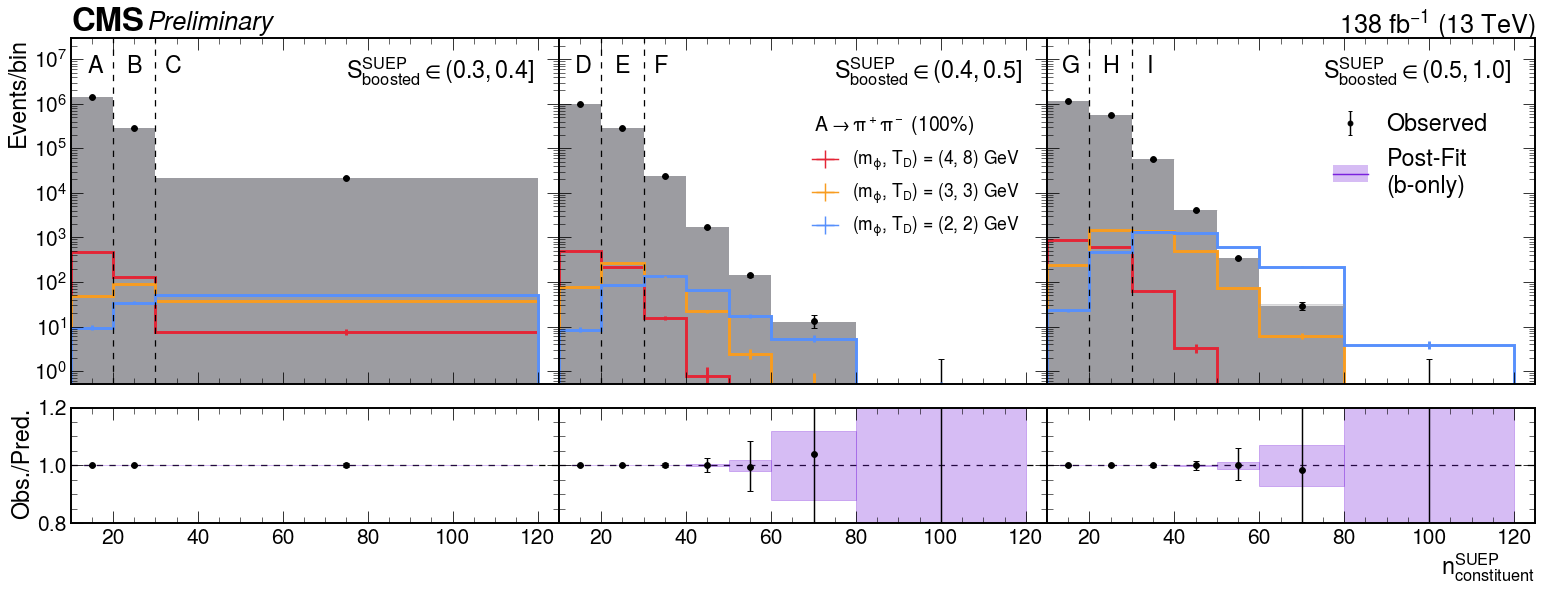

In [22]:
"""
make_postfit function:
- plot_objs: dictionary of histograms and their properties (don't need to change)
- channel: 'WH' or 'ZH'
- region: 'SR' or 'GJLS' or 'WJLS' (or any other region)
- signals: list of tuples containing (mD, T, mode) for signal histograms (integers for mD and T unless non-integer T, then pass as float)
- postfits: 'b', 's+b', or 'both'
- prefit: boolean to indicate if prefit should be plotted

for debugging... convention that has been set is ch1=ZH and ch2=WH
expected file strucutre and naming scheme follows that set by the official-cards/ directory...
"""

WH_SR_plot_objs = create_plot_objects(payload_WH['SR'], payload_WH_err['SR'], channelnum='ch2')

WH_SRfig, WH_SRaxs, WH_SRaxrs = make_postfit(WH_SR_plot_objs, channel='WH', region='SR', signals=[(4, 8, 'generic'), (3, 3, 'generic'), (2, 2, 'generic')], postfits='b', prefit=False)

WH_SRaxs[0].set_ylim(5e-1, 3e7)
WH_SRaxs[1].set_ylim(5e-1, 3e7)
WH_SRaxs[2].set_ylim(5e-1, 3e7)

 # Hardcoded text labels for each subplot
WH_SRaxs[0].text(0.05, 0.95, 'A', ha='center', va='top', fontsize=24, transform=WH_SRaxs[0].transAxes)
WH_SRaxs[0].text(0.13, 0.95, 'B', ha='center', va='top', fontsize=24, transform=WH_SRaxs[0].transAxes)
WH_SRaxs[0].text(0.21, 0.95, 'C', ha='center', va='top', fontsize=24, transform=WH_SRaxs[0].transAxes)

WH_SRaxs[1].text(0.05, 0.95, 'D', ha='center', va='top', fontsize=24, transform=WH_SRaxs[1].transAxes)
WH_SRaxs[1].text(0.13, 0.95, 'E', ha='center', va='top', fontsize=24, transform=WH_SRaxs[1].transAxes)
WH_SRaxs[1].text(0.21, 0.95, 'F', ha='center', va='top', fontsize=24, transform=WH_SRaxs[1].transAxes)

WH_SRaxs[2].text(0.05, 0.95, 'G', ha='center', va='top', fontsize=24, transform=WH_SRaxs[2].transAxes)
WH_SRaxs[2].text(0.13, 0.95, 'H', ha='center', va='top', fontsize=24, transform=WH_SRaxs[2].transAxes)
WH_SRaxs[2].text(0.21, 0.95, 'I', ha='center', va='top', fontsize=24, transform=WH_SRaxs[2].transAxes)

WH_SRaxs[0].text(0.95, 0.95, '$S^{\mathrm{SUEP}}_{\mathrm{boosted}} \in (0.3, 0.4]$', transform=WH_SRaxs[0].transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
WH_SRaxs[1].text(0.95, 0.95, '$S^{\mathrm{SUEP}}_{\mathrm{boosted}} \in (0.4, 0.5]$', transform=WH_SRaxs[1].transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')
WH_SRaxs[2].text(0.95, 0.95, '$S^{\mathrm{SUEP}}_{\mathrm{boosted}} \in (0.5, 1.0]$', transform=WH_SRaxs[2].transAxes, fontsize=24, verticalalignment='top', horizontalalignment='right')

WH_SRaxs[0].yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
WH_SRaxs[0].yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
WH_SRaxs[0].yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
WH_SRaxs[0].yaxis.set_minor_formatter(ticker.NullFormatter())

WH_SRaxs[1].yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
WH_SRaxs[1].yaxis.set_major_formatter(ticker.NullFormatter())
WH_SRaxs[1].yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
WH_SRaxs[1].yaxis.set_minor_formatter(ticker.NullFormatter())

WH_SRaxs[2].yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
WH_SRaxs[2].yaxis.set_major_formatter(ticker.NullFormatter())
WH_SRaxs[2].yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
WH_SRaxs[2].yaxis.set_minor_formatter(ticker.NullFormatter())

WH_SRaxs[1].legend(bbox_to_anchor=(0.98, 0.73), fontsize=18, loc='upper right')
WH_SRaxs[1].text(0.85, 0.78, "$A \\rightarrow \pi^+\pi^-$ (100%)", va='top', ha='right',
        fontsize=20, transform=WH_SRaxs[1].transAxes)

# cms = WH_SRaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=WH_SRaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# simulation = WH_SRaxs[0].text(
#     0.12, 1.01, u"Preliminary",
#     fontsize=24, fontstyle='italic',
#     transform=WH_SRaxs[0].transAxes, 
#     horizontalalignment='left'
# )
hep.cms.label(ax=WH_SRaxs[0], llabel="Preliminary", rlabel="")
saveToPAS = False
PAS_postfit = '/home/submit/lavezzo/SUEP/PAS/EXO-24-030/images/' + 'WH_prepostfit_mD3_T3_mD2_T2_mD4_T8.pdf'
WH_SRfig.tight_layout()
if saveToPAS: WH_SRfig.savefig(PAS_postfit, bbox_inches='tight')
save_to_AN = False
if save_to_AN: WH_SRfig.savefig(AN_label.format('prepostfit'))
WH_SRfig.savefig('/home/submit/lavezzo/public_html/WH/WH_prepostfit_mD3_T3.png',dpi=300, transparent=True, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------------------------------------------------------------------------------

# ZH_SR_plot_objs = create_plot_objects(payload_ZH['ch1_SR'], payload_ZH_err['ch1_SR'], channelnum='ch1')

# ZH_SRfig, ZH_SRaxs, ZH_SRaxrs = make_postfit(ZH_SR_plot_objs, channel='ZH', region='SR', signals=[(8, 32, 'generic')], postfits='s+b', prefit=True)

# ZH_SRaxs[2].text(0.68, 0.77, 'Z + SUEP',
#             fontsize=20, transform=ZH_SRaxs[2].transAxes)
# cms = ZH_SRaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=ZH_SRaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# simulation = ZH_SRaxs[0].text(
#     0.12, 1.01, u"Preliminary",
#     fontsize=24, fontstyle='italic',
#     transform=ZH_SRaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# save_to_AN = False
# if save_to_AN: ZH_SRfig.savefig(AN_label.format('prepostfit'))
# plot_utils.savefig(ZH_SRfig, '../' 'ZH_prepostfit_mD3_T3')
# plt.show()

# WJHS_plot_objs = create_plot_objects(payload['WJHS'], payload_err['WJHS'], lepton='e')
# WJHSfig, WJHSaxs, WJHSaxrs = make_postfit(WJHS_plot_objs, region='WJHS', signals=[(3, 3, 'generic')])
# WJHSaxs[2].text(0.68, 0.77, 'W + jets',
#             fontsize=20, transform=WJHSaxs[2].transAxes)
# cms = WJHSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=WJHSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# simulation = WJHSaxs[0].text(
#     0.12, 1.01, u"Preliminary",
#     fontsize=24, fontstyle='italic',
#     transform=WJHSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# if save_to_AN: WJHSfig.savefig(AN_label.format('prepostfit'))

# WJLS_plot_objs = create_plot_objects(payload['WJLS'], payload_err['WJLS'])
# WJLSfig, WJLSaxs, WJLSaxrs = make_postfit(WJLS_plot_objs, region='WJLS')
# WJLSaxrs[2].text(0.68, 0.77, 'W + jets',
#             fontsize=20, transform=WJLSaxrs[2].transAxes)
# cms = WJLSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=WJLSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# GJLS_plot_objs = create_plot_objects(payload['GJLS'], payload_err['GJLS'])
# GJLSfig, GJLSaxs, GJLSaxrs = make_postfit(GJLS_plot_objs, region='GJLS')
# GJLSaxs[2].text(0.68, 0.77, '$\gamma$ + jets',
#             fontsize=20, transform=GJLSaxs[2].transAxes)
# cms = GJLSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=GJLSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# GJHS_plot_objs = create_plot_objects(payload['GJHS'], payload_err['GJHS'])
# GJHSfig, GJHSaxs, GJHSaxrs = make_postfit(
#     GJHS_plot_objs, region='GJHS',
#     signals=[(2, 2, 'generic'), (4, 4, 'generic'), (8, 8, 'generic')]
# )
# GJHSaxs[2].text(0.68, 0.77, '$\gamma$ + jets',
#             fontsize=20, transform=GJHSaxs[2].transAxes)
# cms = GJHSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=GJHSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# _ = GJHSaxs[0].set_ylim(5e-1, 1e8)
# _ = GJHSaxs[1].set_ylim(5e-1, 1e8)
# _ = GJHSaxs[2].set_ylim(5e-1, 1e8)
# _ = GJHSaxrs[0].set_ylim(0.5, 1.3)
# _ = GJHSaxrs[1].set_ylim(0.5, 1.3)
# _ = GJHSaxrs[2].set_ylim(0.5, 1.3)

# if save_to_AN: GJHSfig.savefig(AN_label.format('VRGJ_prepostfit'))

# HEPData stuff

Pre, post-fit

In [ ]:
def make_hepdata(_rpayload, _rpayload_err):

    bins = [
        'A', 'B', 'C', 'D', 'E', 'F_Fbin0','F_Fbin1','F_Fbin2','F_Fbin3','F_Fbin4', 'G', 'H', 'SR_SRbin0','SR_SRbin1','SR_SRbin2','SR_SRbin3','SR_SRbin4'
    ]
    bin_edges = [
        [10, 20], [20, 30], [30, float('inf')], [10, 20], [20, 30], [30, 40], [40, 50], [50, 60], [60, 80], [80, float('inf')], [10, 20], [20, 30], [30, 40], [40, 50], [50, 60], [60, 80], [80, float('inf')]
    ]
    out = {}
    out['bins'] = bins
    out['bin_edges'] = bin_edges

    # post fit values for each region
    values = np.array([_rpayload['SR']['fit_b'][bin] for bin in bins])
    errors = np.array([_rpayload_err['SR']['fit_b'][bin] for bin in bins])
    out['fit_b'] = values.tolist()
    out['fit_b_err'] = errors.tolist()

    # observed data for each region
    values = np.array([_rpayload['SR']['data'][b] for b in bins])
    errors = np.array([_rpayload_err['SR']['data'][bin] for bin in bins])
    errors[np.isnan(errors)] = 0
    out['data'] = values.tolist()
    out['data_err'] = np.array([values-errors[:,0], errors[:,1] - values]).T.tolist()
    
    return out

import json
hepdata = make_hepdata(payload, payload_err)

with open('Entry/hepdata_fit_wh.json', 'w') as f:
    json.dump(hepdata, f)

Signal cutflow table

In [ ]:
import sys
sys.path.append("/home/submit/lavezzo/SUEP/SUEPCoffea_dask") # a bit hardcoded...
sys.path.append("/home/submit/lavezzo/SUEP/SUEPCoffea_dask/plotting")

from plotting.utils.loader import loader, getHistList
from plotting.utils import plot_utils as other_plot_utils

In [ ]:
local_hist_dir = "/ceph/submit/data/user/l/lavezzo/SUEP/outputs/"

files_signals = []
files_signals += getHistList(local_hist_dir, "WH_11_21_signal_2018",  "/home/submit/lavezzo/SUEP/SUEPCoffea_dask/filelist/WH/list_2018_signal_generic.txt", file_ext=".pkl")
cutflow_signals = loader(files_signals, by_year=False, only_cutflows=True)

In [ ]:
selections = [
    'cutflow_total_nominal',
    'cutflow_allTriggers_nominal',
    'cutflow_qualityFilters_nominal',
    'cutflow_orthogonality_nominal',
    'cutflow_oneTightLepton_nominal',
    'cutflow_oneAK4jet_nominal',
    'cutflow_MET20_nominal',
    'cutflow_twoTracksInCluster_nominal',
    'cutflow_PuppiMET_pt_>_30.0_SR',
    'cutflow_W_pt_>_60.0_SR',
    'cutflow_W_mt_>_30.0_SR',
    'cutflow_bjetSel_==_1.0_SR',
    'cutflow_deltaPhi_SUEP_W_>_1.5_SR',
    'cutflow_deltaPhi_SUEP_MET_>_1.5_SR',
    'cutflow_deltaPhi_lepton_SUEP_>_1.5_SR',
    'cutflow_ak4jets_inSUEPcluster_n_HighestPT_>=_1.0_SR',
    'cutflow_W_SUEP_BV_<_2.0_SR',
    'cutflow_deltaPhi_minDeltaPhiMETJet_MET_>_1.5_SR'
]
selection_labels = [
    "Total",
    "Triggers",
    "Quality filters",
    "Orthogonality",
    "One tight lepton",
    "One AK4 jet",
    "MET > 20",
    "One cluster",
    "$p^{miss}_T$ > 30 GeV & Reweighting",
    "$p^{W}_T$ > 60 GeV",
    "30 GeV < $m^{W}_T$ < 130 GeV",
    "b-jet selection",
    "$\Delta\phi(W, SUEP)$ > 1.5",
    "$\Delta\phi(MET, SUEP)$ > 1.5",
    "$\Delta\phi(lepton, SUEP)$ > 1.5",
    ">=1 AK4 jet in SUEP cluster",
    "$p^{W}_{T}/p^{SUEP}_T$ < 3",
    "min($\Delta\phi(MET, Jet)$) > 1.5"
]

In [ ]:
table = other_plot_utils.make_cutflow_table(
    cutflow_signals,
    cutflow_signals.keys(),
    selections,
    relative_efficiencies=True
    #selection_labels, 5
)
table

In [ ]:
def get_signal_params(name):
    import re

    pattern = r'SUEP-WH-mS(\d+)_T(\d+\.\d+)_mPhi(\d+\.\d+)_(\w+)'

    # Use re.search to find the first occurrence of the pattern in the sample name
    match = re.search(pattern, name)

    # Extract the matched groups and convert them to the appropriate data types
    temp = float(match.group(3))
    mS = float(match.group(1))
    mPhi = float(match.group(2))
    decay = match.group(4)
    mAprime = plot_utils.mA[decay]

    # Return the extracted parameters as a tuple
    return mS, mPhi, temp, mAprime

signals = [get_signal_params(s) for s in cutflow_signals.keys()]

In [ ]:
import csv

hep_table = []
hep_table = [['$m_S$ [GeV]', '$m_{\phi}$ [GeV]', '$T_D$ [GeV]', '$m_{A\'}$ [GeV]'] + selection_labels]
for signal, cutflow in zip(signals, table):
    row = list(signal) + list(cutflow)
    hep_table.append(row)

with open('Entry/hepdata_cutflow_wh.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(hep_table)